In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 

In [2]:
df = pd.read_csv(r"C:\Pythin\code\honeyIncome\US_honey_dataset.csv")

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1115 entries, 0 to 1114
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Unnamed: 0           1115 non-null   int64  
 1   state                1115 non-null   str    
 2   colonies_number      1115 non-null   int64  
 3   yield_per_colony     1115 non-null   int64  
 4   production           1115 non-null   int64  
 5   stocks               1115 non-null   int64  
 6   average_price        1115 non-null   float64
 7   value_of_production  1115 non-null   int64  
 8   year                 1115 non-null   int64  
dtypes: float64(1), int64(7), str(1)
memory usage: 78.5 KB


In [4]:
df.head()

,Unnamed: 0,state,colonies_number,yield_per_colony,production,stocks,average_price,value_of_production,year
0,0,Alabama,16000,58,928000,28000,62.0,575000,1995
1,1,Arizona,52000,79,4108000,986000,68.0,2793000,1995
2,2,Arkansas,50000,60,3000000,900000,64.0,1920000,1995
3,3,California,420000,93,39060000,4687000,60.0,23436000,1995
4,4,Colorado,45000,60,2700000,1404000,68.0,1836000,1995


In [5]:
df.isnull().sum()

Unnamed: 0             0
state                  0
colonies_number        0
yield_per_colony       0
production             0
stocks                 0
average_price          0
value_of_production    0
year                   0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.columns

Index(['Unnamed: 0', 'state', 'colonies_number', 'yield_per_colony',
       'production', 'stocks', 'average_price', 'value_of_production', 'year'],
      dtype='str')

In [8]:
df.drop(columns = ['Unnamed: 0'], inplace=True)

In [9]:
df.head(5)

,state,colonies_number,yield_per_colony,production,stocks,average_price,value_of_production,year
0,Alabama,16000,58,928000,28000,62.0,575000,1995
1,Arizona,52000,79,4108000,986000,68.0,2793000,1995
2,Arkansas,50000,60,3000000,900000,64.0,1920000,1995
3,California,420000,93,39060000,4687000,60.0,23436000,1995
4,Colorado,45000,60,2700000,1404000,68.0,1836000,1995


In [10]:
df.columns

Index(['state', 'colonies_number', 'yield_per_colony', 'production', 'stocks',
       'average_price', 'value_of_production', 'year'],
      dtype='str')

In [11]:
df.describe()

,colonies_number,yield_per_colony,production,stocks,average_price,value_of_production,year
count,1115.000000,1115.000000,1.115000e+03,1.115000e+03,1115.000000,1.115000e+03,1115.000000
mean,62438.565022,59.743498,2.851268e+06,1.172625e+06,140.623076,5.667412e+06,2007.740807
std,92648.175955,19.940500,5.561202e+06,2.049556e+06,107.011544,9.459460e+06,7.823002
min,2000.000000,19.000000,1.200000e+04,9.000000e+03,1.300000,1.060000e+05,1995.000000
25%,9000.000000,45.000000,2.460000e+05,1.125000e+05,70.000000,1.008000e+06,2001.000000
50%,26000.000000,57.000000,8.280000e+05,3.700000e+05,128.000000,2.281000e+06,2008.000000
75%,69000.000000,71.000000,2.700000e+06,1.253500e+06,193.000000,5.704000e+06,2015.000000
max,550000.000000,155.000000,3.906000e+07,1.354500e+07,874.000000,8.385900e+07,2021.000000


In [12]:
print(df['year'].min())
print("to")
print(df['year'].max())

1995
to
2021


In [13]:
df.columns

Index(['state', 'colonies_number', 'yield_per_colony', 'production', 'stocks',
       'average_price', 'value_of_production', 'year'],
      dtype='str')

In [14]:
df.head()

,state,colonies_number,yield_per_colony,production,stocks,average_price,value_of_production,year
0,Alabama,16000,58,928000,28000,62.0,575000,1995
1,Arizona,52000,79,4108000,986000,68.0,2793000,1995
2,Arkansas,50000,60,3000000,900000,64.0,1920000,1995
3,California,420000,93,39060000,4687000,60.0,23436000,1995
4,Colorado,45000,60,2700000,1404000,68.0,1836000,1995


In [15]:
#if production is equal to total colonies * yeild per colony 

prod = df['colonies_number']*df['yield_per_colony']

if prod.equals(df['production']):
    print("The production values are equal.")
else:
    print("The production values are not equal.")

The production values are not equal.


In [16]:
df["production"] == df["colonies_number"] * df["yield_per_colony"]

0        True
1        True
2        True
3        True
4        True
        ...  
1110    False
1111    False
1112    False
1113    False
1114    False
Length: 1115, dtype: bool

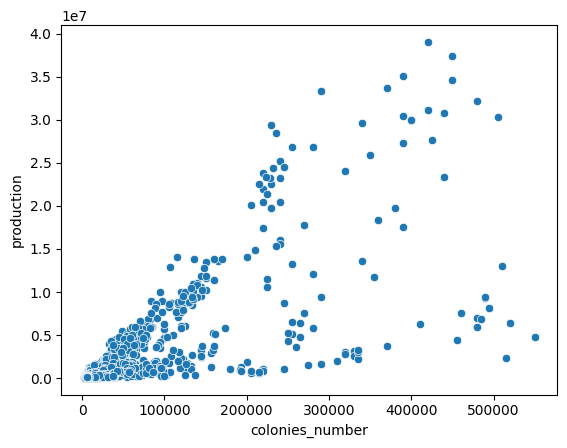

In [17]:
x6 = sns.scatterplot(data = df, x = "colonies_number", y = "production")

 for most the values if the colonines number increase the production is increased also for some it doesnt 

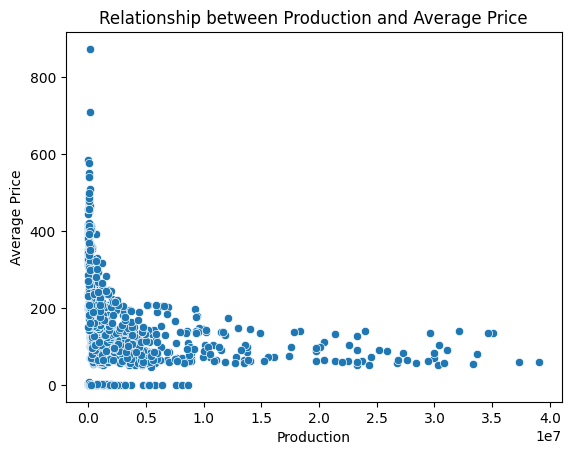

In [18]:
sns.scatterplot(data=df, x="production", y="average_price")
plt.xlabel("Production")
plt.ylabel("Average Price")
plt.title("Relationship between Production and Average Price")
plt.show()

if supplies are dropping the price are increaseing 

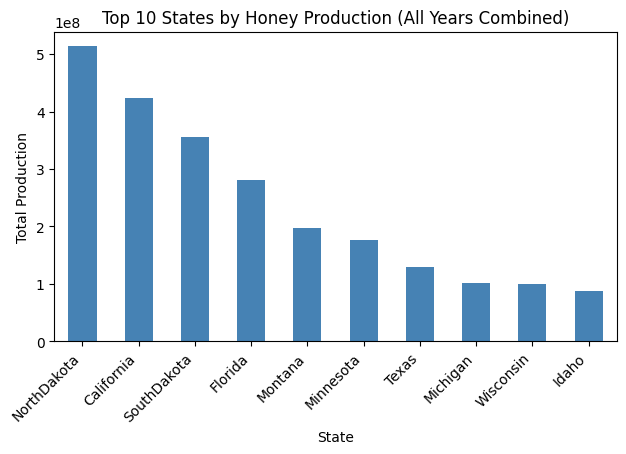

State with highest honey production: NorthDakota
Total production: 513,742,000


In [19]:

# Group by state and sum the production, then find the state with highest total production
state_production = df.groupby('state')['production'].sum().sort_values(ascending=False)

# Get the state with highest production
top_state = state_production.idxmax()

# Create a bar graph showing top 10 states by production
# plt.figure(figsize=(12, 6))
state_production.head(10).plot(kind='bar', color='steelblue')
plt.xlabel('State')
plt.ylabel('Total Production')
plt.title('Top 10 States by Honey Production (All Years Combined)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(f"State with highest honey production: {top_state}")
print(f"Total production: {state_production[top_state]:,.0f}")

<Axes: xlabel='state'>

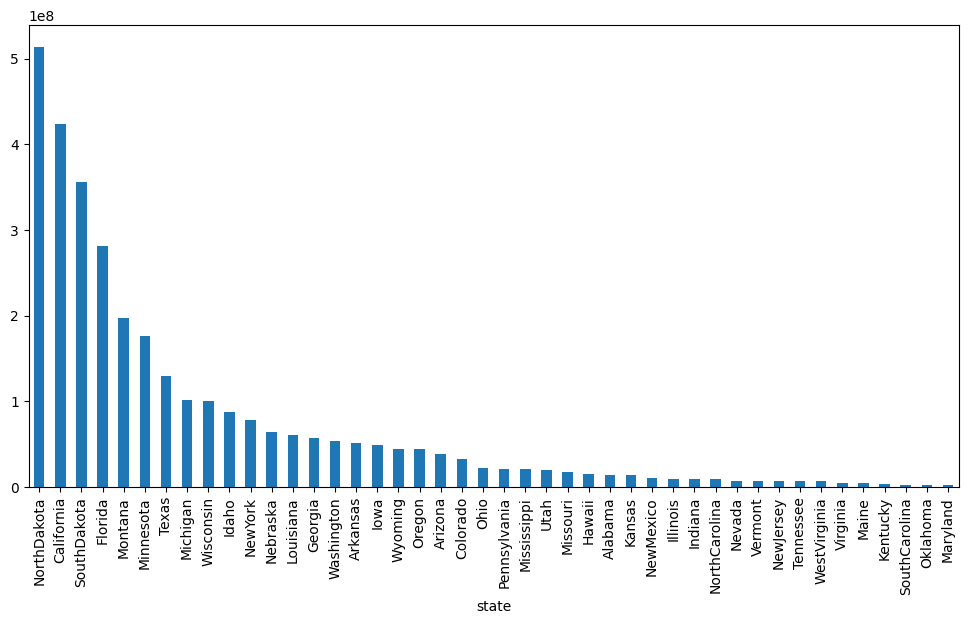

In [20]:
df.groupby('state')['production'].sum().sort_values(ascending=False).plot(kind='bar', figsize=(12,6))

In [21]:
df.groupby('state')['production'].sum().sort_values(ascending=False)

state
NorthDakota      513742000
California       423876000
SouthDakota      355726000
Florida          280934000
Montana          197173000
Minnesota        176581000
Texas            129441000
Michigan         101063000
Wisconsin         99909000
Idaho             87188000
NewYork           78444000
Nebraska          63655000
Louisiana         60568000
Georgia           57426000
Washington        53238000
Arkansas          51846000
Iowa              48607000
Wyoming           43921000
Oregon            43789000
Arizona           38844000
Colorado          32660000
Ohio              22485000
Pennsylvania      21370000
Mississippi       21235000
Utah              20369000
Missouri          17904000
Hawaii            15420000
Alabama           14467000
Kansas            14138000
NewMexico         10082000
Illinois           9864000
Indiana            9686000
NorthCarolina      8909000
Nevada             7399000
Vermont            7032000
NewJersey          6913000
Tennessee          685

<Axes: xlabel='state'>

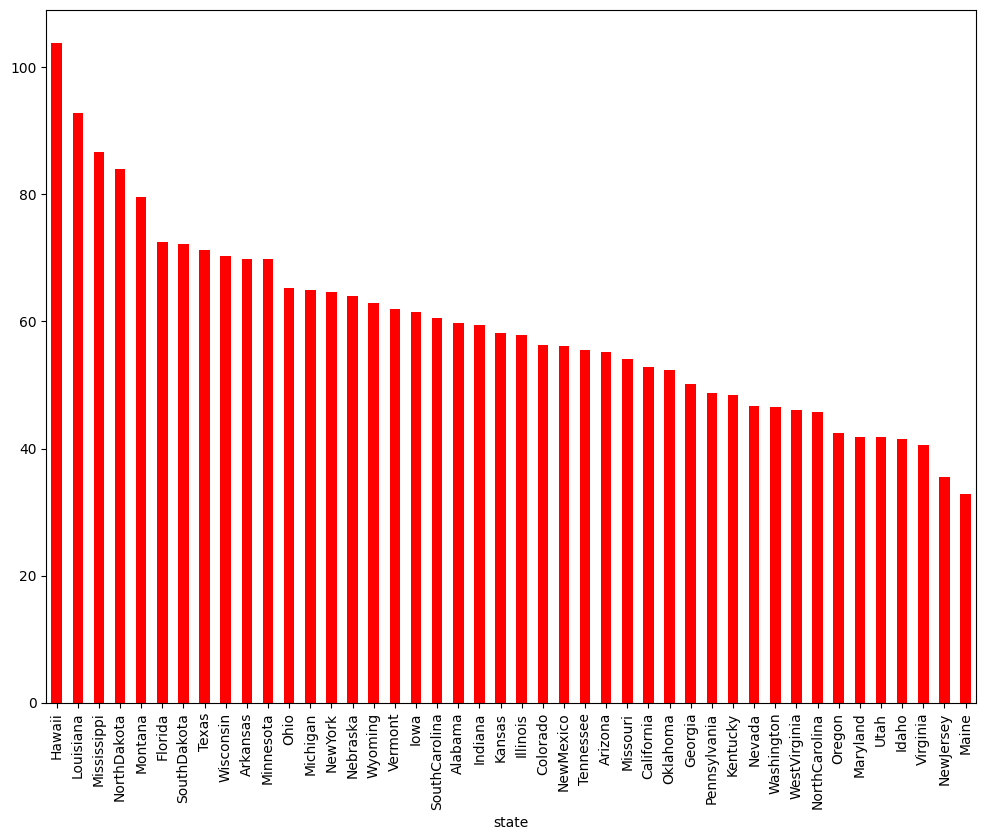

In [30]:
## which state has the highest and the lowest yield per colony? use bar graph

state_yield =  df.groupby('state')['yield_per_colony'].mean().sort_values(ascending=False)
state_yield.plot(kind = 'bar', colormap='hsv', figsize= (12, 9))

In [33]:
df.head()

,state,colonies_number,yield_per_colony,production,stocks,average_price,value_of_production,year
0,Alabama,16000,58,928000,28000,62.0,575000,1995
1,Arizona,52000,79,4108000,986000,68.0,2793000,1995
2,Arkansas,50000,60,3000000,900000,64.0,1920000,1995
3,California,420000,93,39060000,4687000,60.0,23436000,1995
4,Colorado,45000,60,2700000,1404000,68.0,1836000,1995


<Axes: xlabel='year'>

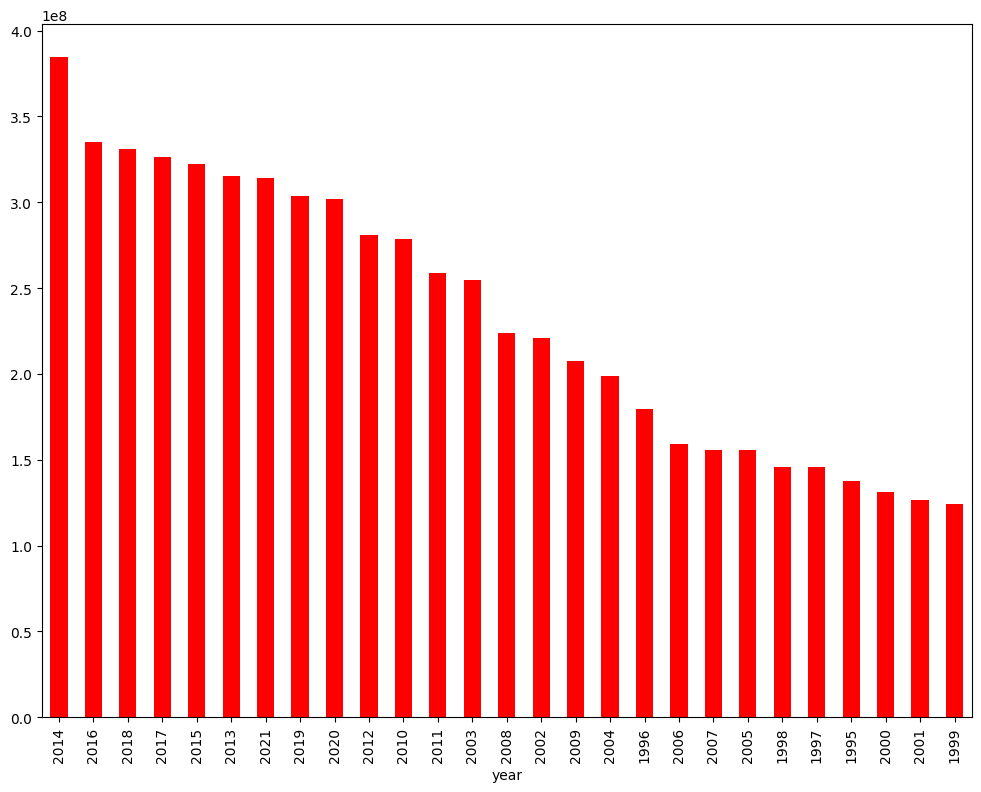

In [34]:
##which year withnessed the highest profit in honey production? use bargraph

year_profit = df.groupby('year')['value_of_production'].sum().sort_values(ascending = False)

year_profit.plot(kind = 'bar', colormap = "hsv", figsize = (12,9))

<Axes: xlabel='state'>

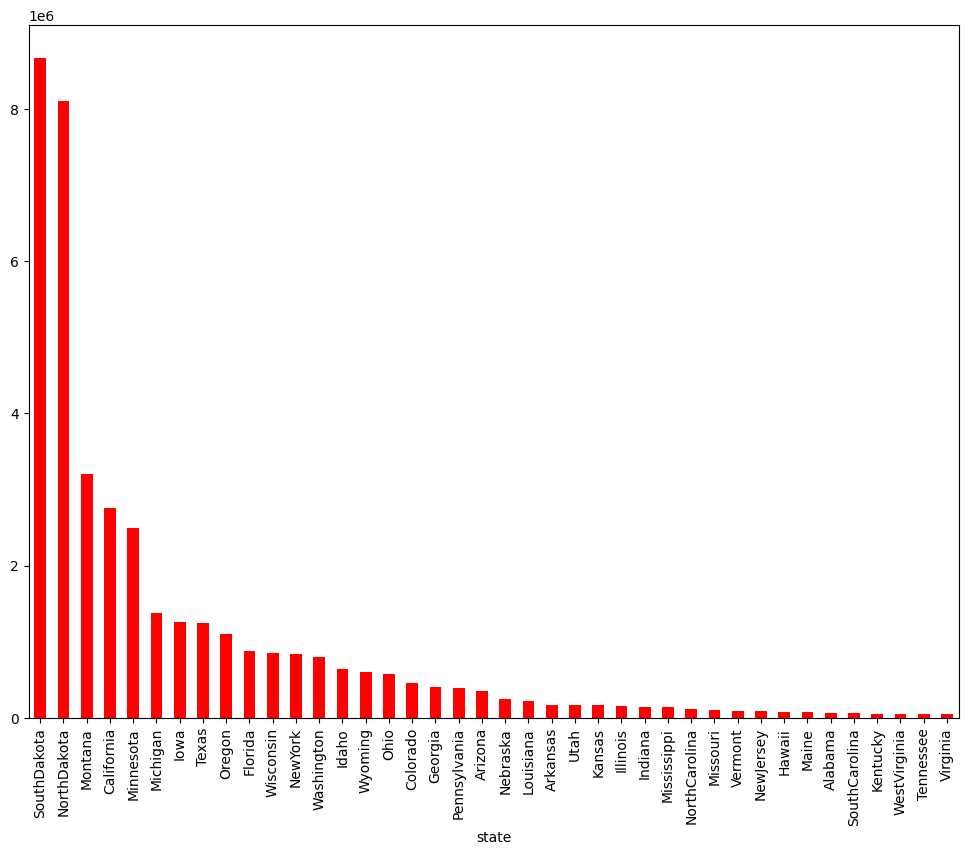

In [36]:
##which state was having the highest stock in 2020 represent using bar graph

stock_2020 = df[df['year']==2020].groupby('state')['stocks'].sum().sort_values(ascending=False)

stock_2020.plot(kind= 'bar', colormap = 'hsv', figsize = (12, 9))

In [41]:
## print the data of the 2020

df5 = df[df['year']==2020].sort_values(by='stocks', ascending = False)

print(df5)

              state  colonies_number  yield_per_colony  production   stocks  \
1065    SouthDakota           245000                61     8668000  8668000   
1060    NorthDakota           495000                78     8108000  8108000   
1055        Montana           110000                81     3208000  3208000   
1038     California           320000                43     2752000  2752000   
1052      Minnesota           108000                55     2495000  2495000   
1051       Michigan            95000                47     1384000  1384000   
1046           Iowa            35000                58     1259000  1259000   
1067          Texas           157000                57     1253000  1253000   
1062         Oregon            95000                29     1102000  1102000   
1040        Florida           192000                46      883000   883000   
1073      Wisconsin            45000                50      855000   855000   
1058        NewYork            58000                

C:\Users\aayan\AppData\Local\Temp\ipykernel_1824\319670403.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  x7 = sns.barplot(data = df5, x= "stocks", y = "state", palette='hsv', ax=ax)


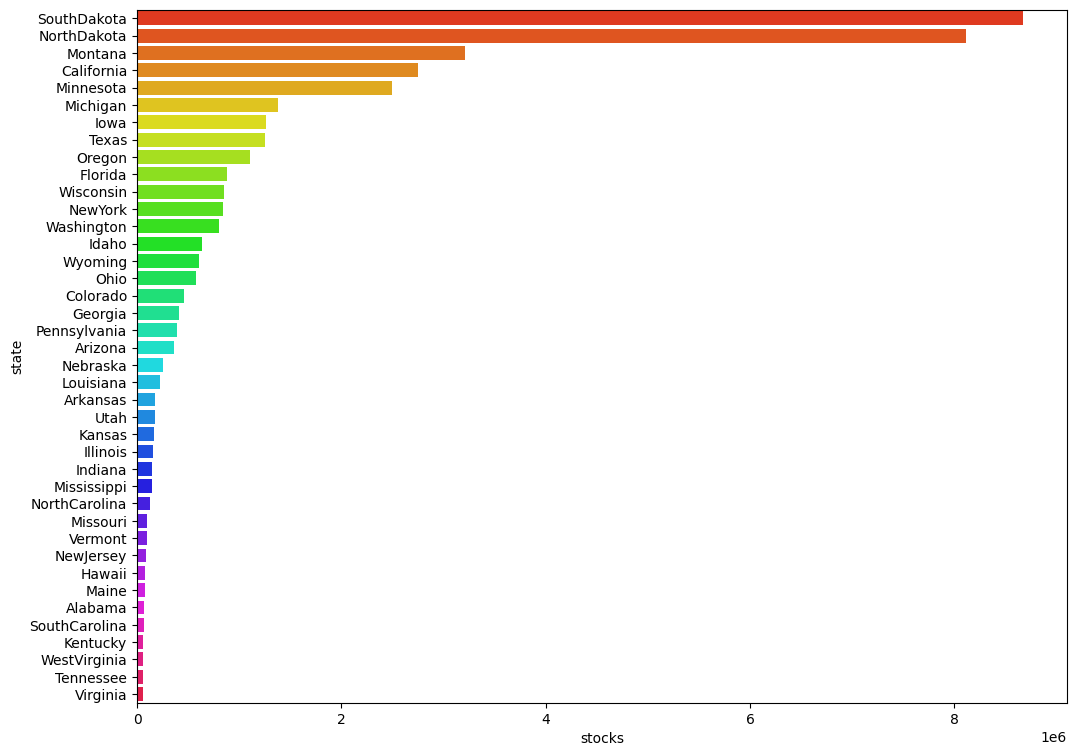

In [47]:
fig, ax = plt.subplots(figsize=(12, 9))
x7 = sns.barplot(data = df5, x= "stocks", y = "state", palette='hsv', ax=ax)


In [57]:
df.columns

Index(['state', 'colonies_number', 'yield_per_colony', 'production', 'stocks',
       'average_price', 'value_of_production', 'year'],
      dtype='str')

<Axes: xlabel='state'>

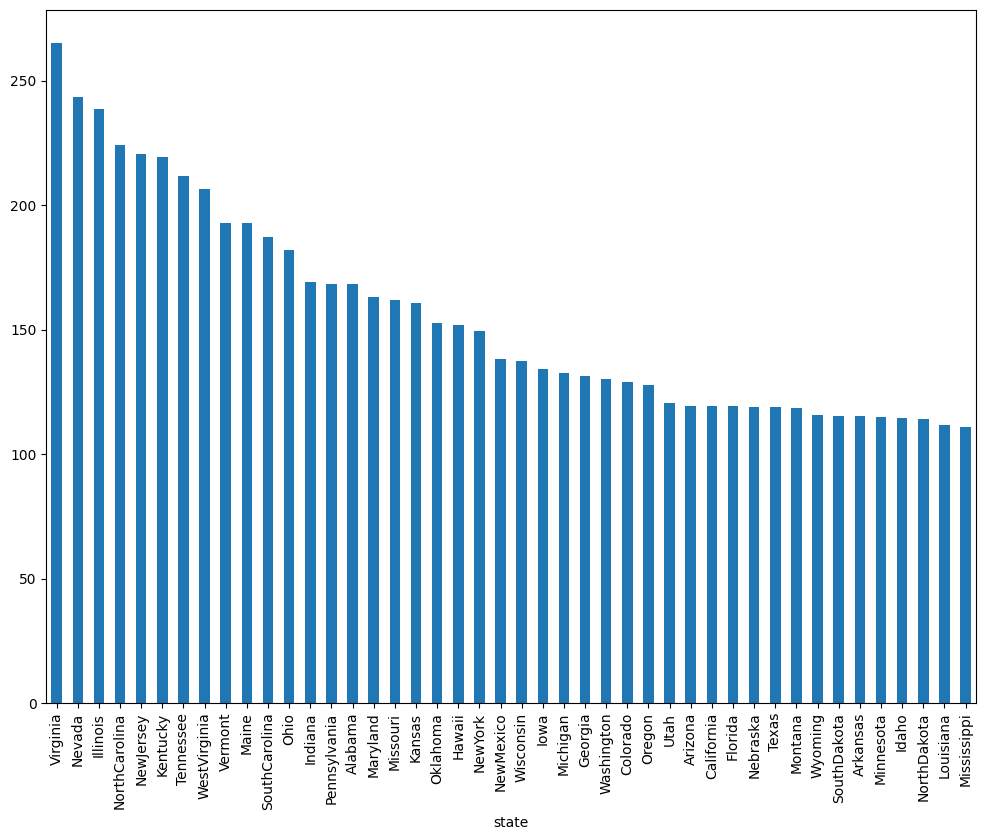

In [60]:
## which state has the highest average price in the 21st century??

highest_price = df[df['year'] >= 2000].groupby("state")['average_price'].mean().sort_values(ascending= False)

highest_price.plot(kind = 'bar', figsize = (12,9))

C:\Users\aayan\AppData\Local\Temp\ipykernel_1824\1343759453.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  x10 = sns.barplot(data = df9, x = 'state', y = 'average_price', palette = 'hsv')


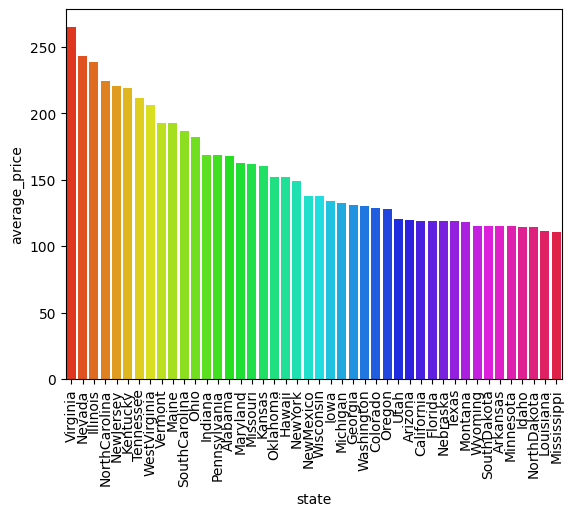

In [63]:
df9 = highest_price.reset_index()

x10 = sns.barplot(data = df9, x = 'state', y = 'average_price', palette = 'hsv')

plt.xticks(rotation = 90)
plt.show()

In [67]:
df.head()

,state,colonies_number,yield_per_colony,production,stocks,average_price,value_of_production,year
0,Alabama,16000,58,928000,28000,62.0,575000,1995
1,Arizona,52000,79,4108000,986000,68.0,2793000,1995
2,Arkansas,50000,60,3000000,900000,64.0,1920000,1995
3,California,420000,93,39060000,4687000,60.0,23436000,1995
4,Colorado,45000,60,2700000,1404000,68.0,1836000,1995


In [70]:
##  show the trend how the production changes over time for the state hawaii



df_hawaii = df[df['state'] == 'Hawaii']
print(df_hawaii)



       state  colonies_number  yield_per_colony  production  stocks  \
7     Hawaii             8000               129     1032000  103000   
51    Hawaii             8000               155     1240000   62000   
95    Hawaii             9000               146     1314000  158000   
138   Hawaii             8000               118      944000   66000   
181   Hawaii             8000                80      640000   32000   
224   Hawaii             7000               112      784000  125000   
267   Hawaii             8000                87      696000   84000   
310   Hawaii             7000               136      952000   29000   
354   Hawaii             7000               113      791000   43000   
398   Hawaii             8000                96      768000   77000   
438   Hawaii             9000               131     1179000  283000   
479   Hawaii            10000                93      930000  233000   
520   Hawaii            10000                92      920000  285000   
561   

<Axes: xlabel='year', ylabel='production'>

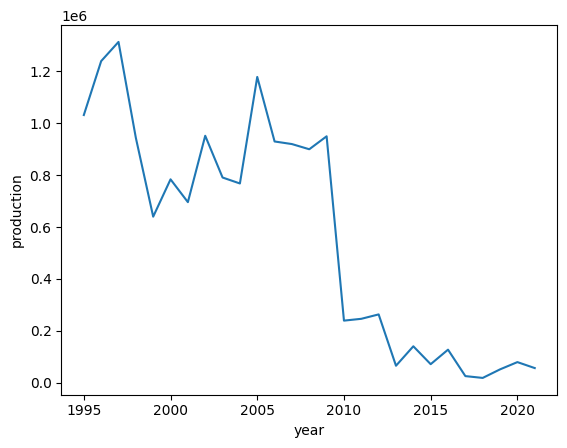

In [72]:
sns.lineplot(data = df_hawaii, x = "year", y = "production")

In [73]:
## compare the 2 highest profitable states of all time on how was their changes in yield_per colony

df.groupby('state')['value_of_production'].sum().sort_values(ascending=False)

state
NorthDakota      1186219000
California        653982000
SouthDakota       619095000
Florida           509670000
Montana           406563000
Minnesota         310462000
Texas             284720000
Michigan          217841000
NewYork           177921000
Wisconsin         176442000
Georgia           145945000
Idaho             139536000
Louisiana         129601000
Washington        119823000
Nebraska          106998000
Oregon            102109000
Iowa               87563000
Wyoming            87502000
Arkansas           73781000
Colorado           63844000
Arizona            59772000
Ohio               59637000
Mississippi        59265000
Pennsylvania       55153000
Hawaii             49888000
Utah               40157000
NorthCarolina      38645000
Illinois           36782000
Missouri           32372000
Alabama            28668000
NewJersey          28201000
Kansas             27970000
Tennessee          27276000
SouthCarolina      26218000
Indiana            24658000
Virginia      

In [ ]:
df15 = df[(df['state']== 'NorthDakota')| (df['state']=='California')]

<Axes: xlabel='year', ylabel='yield_per_colony'>

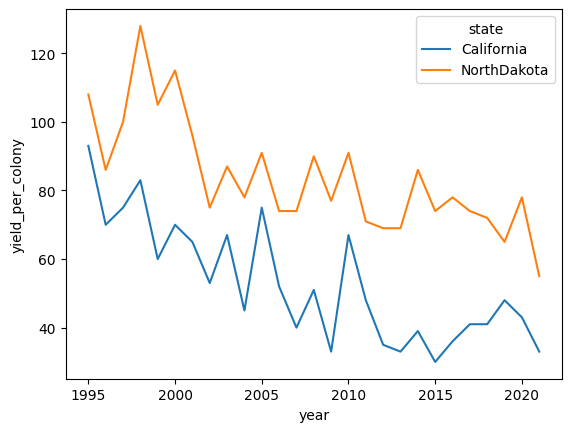

In [77]:
sns.lineplot(data = df15, x = 'year', y = 'yield_per_colony', hue = 'state')